# **Part 2: Vision & Feature Interpretation (Frameworks Allowed)**

Dataset: MNIST Handwritten Digits

Goal: Bridge the gap between pixels and patterns using PyTorch/TensorFlow.

**Question 2.1: Weight Visualization**

● The Task: Build an FCNN using a library (PyTorch/TesorFlow). Once trained, extract the weights of the first hidden layer.

● Deliverable: Reshape the weights of 10 different neurons back into “28 x 28” grids and visualize them as heatmaps.

● Observation: Describe the "shapes" the network is looking for. Are they dots, lines, or just noise?


In [1]:
import random
import numpy as np
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import os

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


In [ ]:
BATCH_SIZE = 128

# Transform for standard fully-connected net: flatten image to 784 vector
flatten_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda t: t.view(-1))  # shape (784,)
])

DATA_DIR = './data_mnist'
os.makedirs(DATA_DIR, exist_ok=True)

raw_dir = Path(DATA_DIR) / "MNIST" / "raw"
if raw_dir.exists():
    for p in raw_dir.glob("*"):
        if p.is_file():
            p.unlink()
raw_dir.mkdir(parents=True, exist_ok=True)

train_ds_normal = datasets.MNIST(DATA_DIR, train=True, download=True, transform=flatten_transform)
test_ds_normal  = datasets.MNIST(DATA_DIR, train=False, transform=flatten_transform)

train_loader_normal = DataLoader(train_ds_normal, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader_normal  = DataLoader(test_ds_normal,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)



100%|██████████| 9.91M/9.91M [02:03<00:00, 80.2kB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 89.9kB/s]
100%|██████████| 1.65M/1.65M [00:03<00:00, 474kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.92MB/s]


In [3]:
# simple FCNN
class FCNet(nn.Module):
    def __init__(self, input_dim=784, h1=512, h2=256, num_classes=10, p_dropout=0.0):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.fc3 = nn.Linear(h2, num_classes)
        self.dropout = nn.Dropout(p_dropout)
        self._init_weights()

    def _init_weights(self):
        # He initialization for ReLU
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        # x shape (batch, 784)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc3(x)
        return x

model = FCNet().to(DEVICE)
print(model)


FCNet(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=10, bias=True)
  (dropout): Dropout(p=0.0, inplace=False)
)


In [4]:
#  training & eval loops 
def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for X, y in dataloader:
        X = X.to(device).float()
        y = y.to(device)
        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += X.size(0)
    return running_loss / total, correct / total

def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(device).float()
            y = y.to(device)
            logits = model(X)
            loss = criterion(logits, y)
            running_loss += loss.item() * X.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += X.size(0)
    return running_loss / total, correct / total


In [5]:
# training runner for one dataset variant
def run_training(train_loader, test_loader, epochs=15, lr=1e-3, weight_decay=0.0,
                 hidden1=512, hidden2=256, dropout=0.0, use_sgd=False, verbose=True):
    model = FCNet(h1=hidden1, h2=hidden2, p_dropout=dropout).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    if use_sgd:
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    else:
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {"train_loss":[], "train_acc":[], "test_loss":[], "test_acc":[]}
    for epoch in range(1, epochs+1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
        te_loss, te_acc = evaluate(model, test_loader, criterion, DEVICE)
        history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
        history["test_loss"].append(te_loss);  history["test_acc"].append(te_acc)
        if verbose:
            print(f"Epoch {epoch:02d}/{epochs}  train_loss={tr_loss:.4f} train_acc={tr_acc:.4f}  test_loss={te_loss:.4f} test_acc={te_acc:.4f}")
    return model, history


In [6]:
# train on normal MNIST
EPOCHS = 15
LR = 1e-3
WD = 0.0
H1, H2 = 512, 256
DROPOUT = 0.2

model_normal, hist_normal = run_training(train_loader_normal, test_loader_normal,
                                         epochs=EPOCHS, lr=LR, weight_decay=WD,
                                         hidden1=H1, hidden2=H2, dropout=DROPOUT, use_sgd=False, verbose=True)


Epoch 01/15  train_loss=0.2710 train_acc=0.9176  test_loss=0.1154 test_acc=0.9655
Epoch 02/15  train_loss=0.1098 train_acc=0.9668  test_loss=0.0897 test_acc=0.9729
Epoch 03/15  train_loss=0.0770 train_acc=0.9756  test_loss=0.0735 test_acc=0.9773
Epoch 04/15  train_loss=0.0599 train_acc=0.9810  test_loss=0.0703 test_acc=0.9777
Epoch 05/15  train_loss=0.0490 train_acc=0.9844  test_loss=0.0639 test_acc=0.9813
Epoch 06/15  train_loss=0.0404 train_acc=0.9873  test_loss=0.0637 test_acc=0.9814
Epoch 07/15  train_loss=0.0357 train_acc=0.9881  test_loss=0.0678 test_acc=0.9802
Epoch 08/15  train_loss=0.0318 train_acc=0.9896  test_loss=0.0667 test_acc=0.9825
Epoch 09/15  train_loss=0.0290 train_acc=0.9900  test_loss=0.0615 test_acc=0.9830
Epoch 10/15  train_loss=0.0279 train_acc=0.9904  test_loss=0.0687 test_acc=0.9806
Epoch 11/15  train_loss=0.0232 train_acc=0.9922  test_loss=0.0664 test_acc=0.9827
Epoch 12/15  train_loss=0.0219 train_acc=0.9924  test_loss=0.0654 test_acc=0.9834
Epoch 13/15  tra

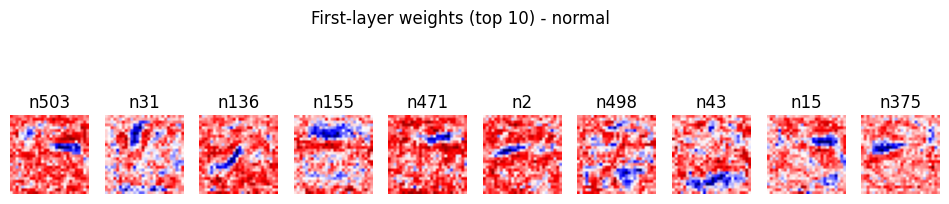

In [7]:
# visualize first-layer weights (pick top-k neurons by L2 norm)
def imshow_flat(vec, title=None, cmap='seismic'):
    img = vec.reshape(28,28)
    plt.imshow(img, cmap=cmap)
    plt.axis('off')
    if title:
        plt.title(title)

def visualize_first_layer_weights(model, k=10, prefix='normal'):
    W = model.fc1.weight.data.cpu().numpy()  # shape (H1, 784)
    norms = np.linalg.norm(W, axis=1)
    idx = np.argsort(-norms)[:k]  # top k
    plt.figure(figsize=(12, 3))
    for i, neuron in enumerate(idx):
        plt.subplot(1, k, i+1)
        imshow_flat(W[neuron], title=f'n{neuron}', cmap='seismic')
    plt.suptitle(f'First-layer weights (top {k}) - {prefix}')
    plt.show()

visualize_first_layer_weights(model_normal, k=10, prefix='normal')

**Question 2.2: The "Flattening" Experiment**

● The Task: Randomly shuffle the pixels of every image in the MNIST dataset (use the same shuffle pattern for all images). Train your FCNN on this "scrambled" data.

● Deliverable: Compare the accuracy of the model on "Normal MNIST" vs. "Scrambled MNIST."

● Observation: Why does the FCNN perform almost identically on both, while a human would find the scrambled version impossible? (This highlights the lack of spatial awareness in FCNNs)

In [8]:
# helper utilities (scramble function, plotting)
def make_pixel_permutation(seed=SEED):
    rng = np.random.RandomState(seed)
    perm = rng.permutation(28 * 28)
    return perm

def scramble_image_flattened(x_tensor, perm):
    # x_tensor: torch tensor shape (784,) or (1, 784)
    # perm: numpy array of length 784
    flat = x_tensor.view(-1).cpu().numpy()
    scrambled = flat[perm]
    return torch.from_numpy(scrambled).float()

class ScrambledMNISTTransform:
    """Transform object to scramble pixels after flattening."""
    def __init__(self, perm):
        self.perm = perm

    def __call__(self, pil_img):
        # Return a flattened tensor of size (784,)
        t = transforms.ToTensor()(pil_img)  # shape (1,28,28)
        t = t.view(-1)  # flatten 784
        t = t[self.perm]
        return t



In [9]:
# Create perm
perm = make_pixel_permutation(seed=SEED)

# Transforms
scramble_transform = ScrambledMNISTTransform(perm)

train_ds_scrambled = datasets.MNIST(DATA_DIR, train=True, download=False, transform=scramble_transform)
test_ds_scrambled  = datasets.MNIST(DATA_DIR, train=False, transform=scramble_transform)

train_loader_scrambled = DataLoader(train_ds_scrambled, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader_scrambled  = DataLoader(test_ds_scrambled,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("Datasets created. Example perm[0:10]:", perm[:10])


Datasets created. Example perm[0:10]: [598 590 209 637 174 213 429 259 593 204]


In [10]:
# train on scrambled MNIST (same hyperparams & seed)
model_scrambled, hist_scrambled = run_training(train_loader_scrambled, test_loader_scrambled,
                                               epochs=EPOCHS, lr=LR, weight_decay=WD,
                                               hidden1=H1, hidden2=H2, dropout=DROPOUT, use_sgd=False, verbose=True)


Epoch 01/15  train_loss=0.2665 train_acc=0.9200  test_loss=0.1086 test_acc=0.9669
Epoch 02/15  train_loss=0.1099 train_acc=0.9665  test_loss=0.0835 test_acc=0.9727
Epoch 03/15  train_loss=0.0763 train_acc=0.9762  test_loss=0.0700 test_acc=0.9770
Epoch 04/15  train_loss=0.0605 train_acc=0.9805  test_loss=0.0669 test_acc=0.9780
Epoch 05/15  train_loss=0.0477 train_acc=0.9842  test_loss=0.0652 test_acc=0.9788
Epoch 06/15  train_loss=0.0412 train_acc=0.9860  test_loss=0.0611 test_acc=0.9822
Epoch 07/15  train_loss=0.0355 train_acc=0.9889  test_loss=0.0592 test_acc=0.9825
Epoch 08/15  train_loss=0.0307 train_acc=0.9897  test_loss=0.0608 test_acc=0.9813
Epoch 09/15  train_loss=0.0288 train_acc=0.9903  test_loss=0.0638 test_acc=0.9814
Epoch 10/15  train_loss=0.0230 train_acc=0.9923  test_loss=0.0598 test_acc=0.9834
Epoch 11/15  train_loss=0.0243 train_acc=0.9916  test_loss=0.0656 test_acc=0.9826
Epoch 12/15  train_loss=0.0225 train_acc=0.9927  test_loss=0.0702 test_acc=0.9815
Epoch 13/15  tra

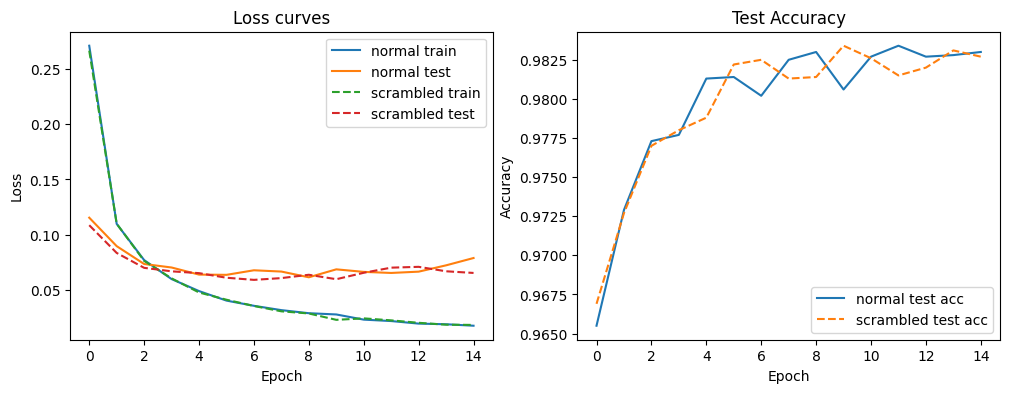

In [11]:
# plot training curves (compare)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(hist_normal['train_loss'], label='normal train')
plt.plot(hist_normal['test_loss'], label='normal test')
plt.plot(hist_scrambled['train_loss'], '--', label='scrambled train')
plt.plot(hist_scrambled['test_loss'], '--', label='scrambled test')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.title('Loss curves')

plt.subplot(1,2,2)
plt.plot(hist_normal['test_acc'], label='normal test acc')
plt.plot(hist_scrambled['test_acc'], '--', label='scrambled test acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.title('Test Accuracy')
plt.show()


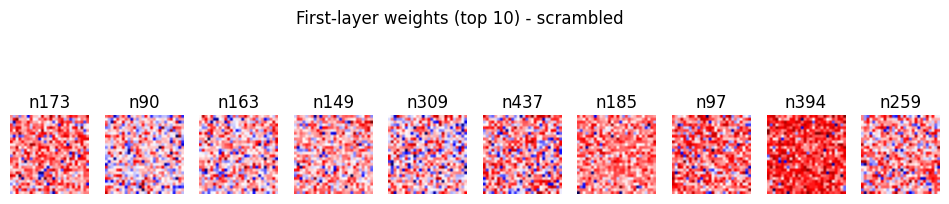

In [12]:
visualize_first_layer_weights(model_scrambled, k=10, prefix='scrambled')


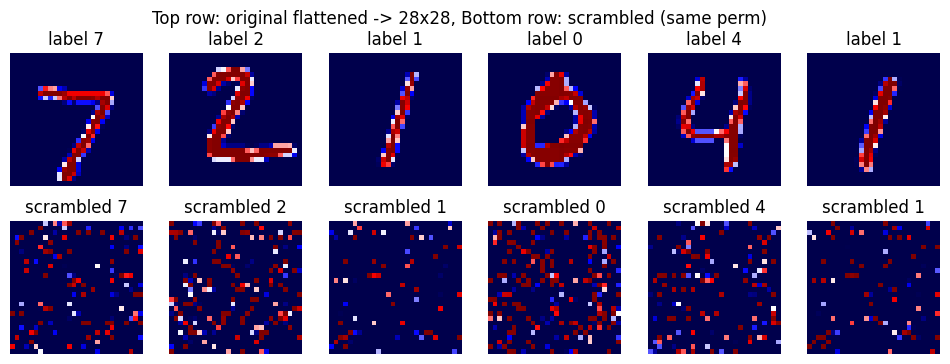

In [13]:
#showing a few example original vs scrambled images
examples = 6
plt.figure(figsize=(12,4))
for i in range(examples):
    img, label = test_ds_normal[i]
    scrambled_flat = test_ds_scrambled[i][0].numpy()
    plt.subplot(2, examples, i+1)
    imshow_flat(img.numpy(), title=f'label {label}')
    plt.subplot(2, examples, i+1+examples)
    imshow_flat(scrambled_flat, title=f'scrambled {label}')
plt.suptitle('Top row: original flattened -> 28x28, Bottom row: scrambled (same perm)')
plt.show()


In [14]:
# print final test accuracies
print("Final normal test acc:", hist_normal['test_acc'][-1])
print("Final scrambled test acc:", hist_scrambled['test_acc'][-1])


Final normal test acc: 0.983
Final scrambled test acc: 0.9827
